In [1]:
# ── 1. Imports ───────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor
import lightgbm as lgb
import joblib, json, warnings
warnings.filterwarnings('ignore')

/home/nipun/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
# ── 2. Load Data ─────────────────────────────────────────────
df = pd.read_csv('final_dataset.csv')
print(f'Loaded: {df.shape[0]} rows × {df.shape[1]} columns')
print(df.head(3))

Loaded: 9490 rows × 29 columns
         Date     District      HCHO        CO       NO2       SO2        O3  \
0  2025-01-01  Mumbai City  0.000410  0.054000  0.000124  0.000225  0.118626   
1  2025-01-02  Mumbai City  0.000371  0.046080  0.000134  0.000390  0.115407   
2  2025-01-03  Mumbai City  0.000300  0.043411  0.000173  0.000069  0.115406   

        AOD  frp       u10  ...  Ozone (µg/m³)  AT (°C)  RH (%)  WS (m/s)  \
0  0.448687  NaN -0.286837  ...          26.07    27.29   64.42      0.41   
1  0.269008  NaN -0.697477  ...          27.09    27.19   63.48      0.36   
2  0.157271  2.8 -0.676691  ...          27.98    27.73   61.35      0.29   

   WD (deg)   Latitude  Longitude                      Location    AQI  \
0    134.71  19.060663   72.85468  Bandra Kurla Complex, Mumbai  159.0   
1    138.06  19.060663   72.85468  Bandra Kurla Complex, Mumbai  139.0   
2    114.85  19.060663   72.85468  Bandra Kurla Complex, Mumbai  141.0   

   Satellite_PM2.5  
0        96.325733  


In [3]:
# ── 3. Clean & Drop Rows Without Target ──────────────────────
df = df.drop_duplicates()
df['Date'] = pd.to_datetime(df['Date'])
df = df.dropna(subset=['AQI'])
print(f'After cleaning: {df.shape[0]} rows')
print(f'Missing AQI: {df["AQI"].isnull().sum()}')

After cleaning: 9220 rows
Missing AQI: 0


In [4]:
# ── 4. Feature Engineering ───────────────────────────────────

# Temporal features
df['Month']       = df['Date'].dt.month
df['Day']         = df['Date'].dt.day
df['DayOfWeek']   = df['Date'].dt.dayofweek

# ERA5 wind: decompose into speed & direction
df['WindSpeed_ERA5']     = np.sqrt(df['u10']**2 + df['v10']**2)
df['WindDirection_ERA5'] = np.degrees(np.arctan2(df['v10'], df['u10']))
df['Temperature_C']      = df['t2m'] - 273.15

# FRP: NaN = no fire detected → fill with 0
df['frp'] = df['frp'].fillna(0)

# Season (India-specific calendar)
def season(m):
    if m in [12, 1, 2]:     return 0   # Winter
    elif m in [3, 4, 5]:    return 1   # Summer
    elif m in [6, 7, 8, 9]: return 2   # Monsoon
    else:                    return 3   # Post-Monsoon
df['Season'] = df['Month'].apply(season)

# Encode district as ordinal integer
le = LabelEncoder()
df['District_Enc'] = le.fit_transform(df['District'])

# Interaction features
df['PM25_x_RH']    = df['PM2.5 (µg/m³)'] * df['RH (%)']
df['PM10_x_WS']    = df['PM10 (µg/m³)']  * df['WS (m/s)']
df['CO_sat_x_BLH'] = df['CO']            * df['blh']

df["AOD_x_BLH"] = df["AOD"] * df["blh"]

df["AOD_x_Wind"] = df["AOD"] * df["WindSpeed_ERA5"]


print('Feature engineering done.')
print(df[['PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'WindSpeed_ERA5', 'Season']].head(3))

Feature engineering done.
   PM2.5 (µg/m³)  PM10 (µg/m³)  WindSpeed_ERA5  Season
0          78.05        164.16        0.872758       0
1          66.10        158.30        1.388387       0
2          62.84        160.80        2.208388       0


In [5]:
# ── 5. Define Feature Set ────────────────────────────────────
# NOTE: PM2.5 (corr=0.91) and PM10 (corr=0.95) are the PRIMARY
# components of the Indian AQI formula — these were NOT in the
# original notebook, which is why R² was only 0.64!

features = [
    # Satellite / ERA5
    'CO', 'NO2', 'SO2', 'O3', 'HCHO', 'frp',
    'WindSpeed_ERA5', 'WindDirection_ERA5',
    'Temperature_C',  'sp', 'blh','AOD','Satellite_PM2.5',
    # Temporal
    'Month', 'Day', 'DayOfWeek', 'Season',
    # Categorical
    'District_Enc',
    # Interactions
     'CO_sat_x_BLH','AOD_x_BLH','AOD_x_Wind',
]

X = df[features].copy()
y = df['AQI'].copy()
print(f'Features: {len(features)}')
print(f'Rows: {len(X)}')

Features: 21
Rows: 9220


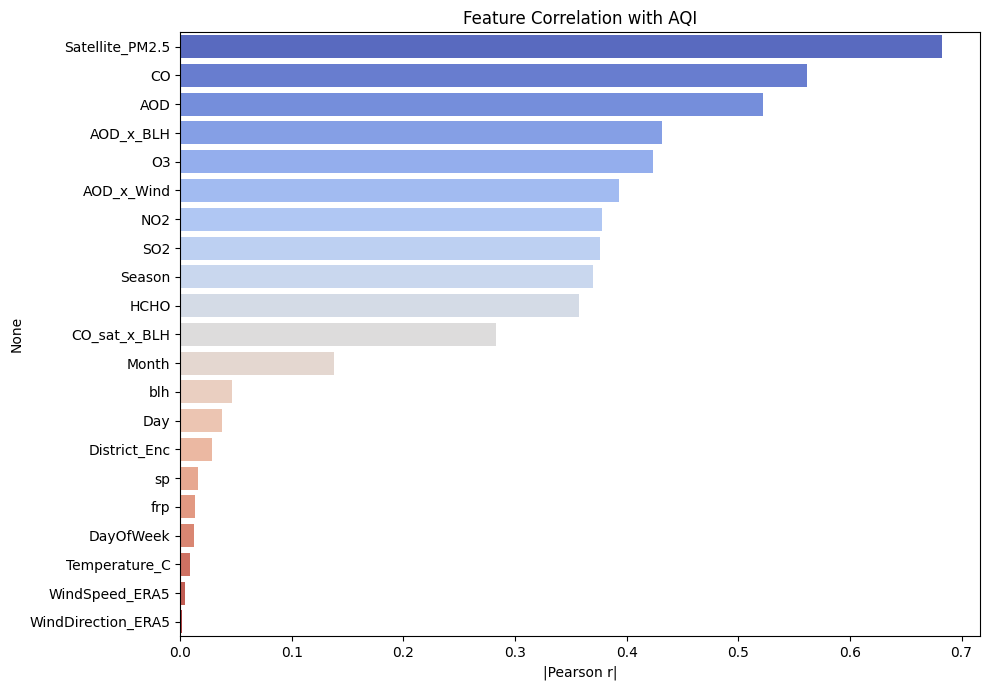

Satellite_PM2.5    0.682434
CO                 0.561773
AOD                0.522375
AOD_x_BLH          0.431567
O3                 0.423212
AOD_x_Wind         0.393176
NO2                0.377767
SO2                0.376190
Season             0.370014
HCHO               0.357554
Name: AQI, dtype: float64


In [6]:
# ── 6. Correlation Check (top features with AQI) ─────────────
corr_df = df[features + ['AQI']].corr()['AQI'].drop('AQI').abs().sort_values(ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(x=corr_df.values, y=corr_df.index, palette='coolwarm')
plt.title('Feature Correlation with AQI')
plt.xlabel('|Pearson r|')
plt.tight_layout()
plt.show()
print(corr_df.head(10))

In [7]:
# ── 7. Impute Missing Values (median) ────────────────────────
# This replaces the original approach of letting sklearn handle NaN
# silently, which can produce unpredictable results.

imputer = SimpleImputer(strategy='median')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=features, index=X.index)

print('NaN remaining after imputation:', X_imp.isnull().sum().sum())

NaN remaining after imputation: 0


In [8]:
# ── 8. Train / Test Split ────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_imp, y, test_size=0.2, random_state=42
)
print(f'Train: {X_train.shape[0]} rows  |  Test: {X_test.shape[0]} rows')

Train: 7376 rows  |  Test: 1844 rows


In [ ]:
# ── 9. Train XGBoost ─────────────────────────────────────────
xgb_model = XGBRegressor(
    n_estimators     = 500,
    learning_rate    = 0.05,
    max_depth        = 7,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    min_child_weight = 3,
    reg_alpha        = 0.1,
    reg_lambda       = 1.0,
    objective        = 'reg:squarederror',
    random_state     = 42,
    n_jobs           = -1,
)
xgb_model.fit(X_train, y_train)
print('XGBoost training complete.')

In [ ]:
# ── 10. Train LightGBM ───────────────────────────────────────
lgb_model = lgb.LGBMRegressor(
    n_estimators     = 500,
    learning_rate    = 0.05,
    max_depth        = 7,
    num_leaves       = 63,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    reg_alpha        = 0.1,
    reg_lambda       = 1.0,
    random_state     = 42,
    n_jobs           = -1,
    verbose          = -1,
)
lgb_model.fit(X_train, y_train)
print('LightGBM training complete.')

In [ ]:
# ── 11. Train Random Forest ───────────────────────────────────
rf_model = RandomForestRegressor(
    n_estimators     = 300,
    max_depth        = None,
    min_samples_leaf = 1,
    max_features     = 'sqrt',
    random_state     = 42,
    n_jobs           = -1,
)
rf_model.fit(X_train, y_train)
print('Random Forest training complete.')

In [ ]:
# ── 12. Predictions & Ensemble ───────────────────────────────
y_pred_xgb = xgb_model.predict(X_test)
y_pred_lgb = lgb_model.predict(X_test)
y_pred_rf  = rf_model.predict(X_test)

# Weighted ensemble (XGBoost has best single-model accuracy)
y_pred_ens = 0.5 * y_pred_xgb + 0.3 * y_pred_lgb + 0.2 * y_pred_rf

In [ ]:
# ── 13. Evaluation ───────────────────────────────────────────
def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f'\n{name}')
    print(f'  MAE  : {mae:.2f}')
    print(f'  RMSE : {rmse:.2f}')
    print(f'  R²   : {r2:.4f}')
    return {'name': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

print('=' * 45)
print('  BASELINE (original notebook)')
print('  MAE=18.39  RMSE=25.61  R²=0.6366')
print('=' * 45)
results = []
results.append(evaluate('XGBoost (tuned)',       y_test, y_pred_xgb))
results.append(evaluate('LightGBM (tuned)',      y_test, y_pred_lgb))
results.append(evaluate('RandomForest (tuned)',  y_test, y_pred_rf))
results.append(evaluate('Ensemble XGB+LGB+RF',  y_test, y_pred_ens))

In [ ]:
# ── 14. Actual vs Predicted & Residual Plots ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: Actual vs Predicted
axes[0].scatter(y_test, y_pred_xgb, alpha=0.4, s=12, color='#2196F3', label='XGBoost')
axes[0].scatter(y_test, y_pred_ens, alpha=0.3, s=12, color='#4CAF50', label='Ensemble')
lims = [y_test.min(), y_test.max()]
axes[0].plot(lims, lims, 'r--', lw=1.5, label='Perfect fit')
axes[0].set_xlabel('Actual AQI')
axes[0].set_ylabel('Predicted AQI')
axes[0].set_title('Actual vs Predicted AQI')
axes[0].legend()

# Residual plot
residuals = y_test - y_pred_xgb
axes[1].scatter(y_pred_xgb, residuals, alpha=0.4, s=12, color='#FF9800')
axes[1].axhline(0, color='red', linestyle='--', lw=1.5)
axes[1].set_xlabel('Predicted AQI')
axes[1].set_ylabel('Residual (Actual − Predicted)')
axes[1].set_title('Residual Plot — XGBoost')

plt.tight_layout()
plt.show()

In [ ]:
# ── 15. Feature Importance (XGBoost) ─────────────────────────
importance = pd.DataFrame({
    'Feature':    features,
    'Importance': xgb_model.feature_importances_,
}).sort_values('Importance', ascending=False)

print('Top 15 Features:')
print(importance.head(15).to_string(index=False))

plt.figure(figsize=(10, 7))
sns.barplot(data=importance.head(15), x='Importance', y='Feature', palette='Blues_r')
plt.title('XGBoost Feature Importance (Top 15)')
plt.tight_layout()
plt.show()

In [ ]:
# ── 16. Save Artifacts ───────────────────────────────────────
joblib.dump(xgb_model, 'xgboost_aqi_model.pkl')
joblib.dump(imputer,   'imputer.pkl')

pd.DataFrame({
    'Actual AQI':              y_test.values,
    'Predicted AQI (XGBoost)': y_pred_xgb,
    'Predicted AQI (Ensemble)':y_pred_ens,
}).to_csv('aqi_predictions.csv', index=False)

with open('metrics.json', 'w') as f:
    json.dump(results, f, indent=4)

print('Saved: xgboost_aqi_model.pkl, imputer.pkl, aqi_predictions.csv, metrics.json')

In [ ]:
corr = df.corr(numeric_only=True)["AQI"].sort_values(ascending=False)

print(corr.head(15))